In [1]:
# ── config ───────────────────────────────────────────────────────────────────
LOGS_ROOT = "/home/robot/workspaces/robot_rodeo_gym_ws/logs"
# Filter to only optuna_ftr_* directories; set to None to include all job types
JOB_PREFIX = None

In [2]:
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# ── regex patterns ────────────────────────────────────────────────────────────
_RE_EXIT       = re.compile(r"finished with exit status:\s*(\d+)")
# re.MULTILINE so ^ matches start-of-line within the full file string
_RE_HEADER_DT  = re.compile(r"^(Mon|Tue|Wed|Thu|Fri|Sat|Sun)\s+(\w+\s+\d+\s+\d+:\d+:\d+\s+\d+)", re.MULTILINE)
_RE_PY_TS      = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})")
# Optuna trial completed
_RE_TRIAL_DONE = re.compile(r"Trial\s+\d+\s+done")
# Standalone training run completed.
# Older sbatch: "Training finished with exit code 0. Not respawning." (no colon)
# Newer sbatch: "Training finished with exit status: 0"              (with colon)
_RE_TRAIN_DONE = re.compile(r"Training finished with exit (?:code|status):?\s*0|Job finished\.", re.IGNORECASE)
# Matches both "Trial 42 pruned" (Optuna API message) and
# "Trial pruned at iteration X" (FtrPPOTrainer internal message)
_RE_TRIAL_PRUNE= re.compile(r"Trial(?:\s+\d+)?\s+pruned|Trial\s+\d+\s+finished with value")
_RE_CANCELLED  = re.compile(r"CANCELLED AT .* DUE TO TIME LIMIT")
_RE_SLURM_KILL = re.compile(r"CANCELLED AT")
_RE_TQDM       = re.compile(r"\[(\d+):(\d{2}):(\d{2})<")
_RE_ARRAY_TASK = re.compile(r"Array task\s*:\s*(\d+)")
_RE_JOB_ARRAY  = re.compile(r"Job array ID\s*:\s*(\d+)")
# Matches CUDA crash messages from Python, Isaac Sim, or PhysX
_RE_CUDA       = re.compile(
    r"CUDA error|Training failed.*CUDA|illegal memory access|CUDA.*out of memory",
    re.IGNORECASE,
)
# Python traceback and exception type detection
_RE_TRACEBACK  = re.compile(r"^Traceback \(most recent call last\):", re.MULTILINE)
# Matches the final exception line: "RuntimeError: ...", "KeyboardInterrupt", etc.
_RE_EXCEPTION_TYPE = re.compile(
    r"^([A-Za-z][A-Za-z0-9_.]*(?:Error|Exception|Interrupt|Warning|Killed))\b",
    re.MULTILINE,
)


def _parse_header_dt(text: str) -> datetime | None:
    """Parse 'Thu Apr 30 19:05:02 2026' from SLURM log header (any line)."""
    m = _RE_HEADER_DT.search(text)
    if not m:
        return None
    date_str = " ".join(m.group(2).split())
    for fmt in ("%b %d %H:%M:%S %Y", "%b  %d %H:%M:%S %Y"):
        try:
            return datetime.strptime(date_str, fmt)
        except ValueError:
            continue
    return None


def _parse_last_py_ts(lines: list[str]) -> datetime | None:
    for line in reversed(lines):
        m = _RE_PY_TS.match(line)
        if m:
            try:
                return datetime.strptime(m.group(1), "%Y-%m-%d %H:%M:%S")
            except ValueError:
                continue
    return None


def _parse_max_tqdm_elapsed(text: str) -> float | None:
    """Return max elapsed seconds seen in any tqdm progress bar line.

    tqdm writes to stderr, so pass err_text here; also works on out_text.
    """
    max_sec = None
    for m in _RE_TQDM.finditer(text):
        h, mm, s = int(m.group(1)), int(m.group(2)), int(m.group(3))
        sec = h * 3600 + mm * 60 + s
        if max_sec is None or sec > max_sec:
            max_sec = sec
    return max_sec


def _extract_exception_types(text: str, err_text: str) -> list[str]:
    """Return unique exception/error class names found in both log files."""
    combined = text + "\n" + err_text
    types = set(_RE_EXCEPTION_TYPE.findall(combined))
    skip = {"Warning", "UserWarning", "FutureWarning", "DeprecationWarning"}
    return sorted(types - skip)


def _infer_job_type(out_path: Path) -> str:
    """Derive job type from the top-level log directory name."""
    parts = out_path.parts
    for i, part in enumerate(parts):
        if part == "logs" and i + 1 < len(parts):
            top = parts[i + 1]
            if top.startswith("optuna_ftr"): return "optuna"
            if top.startswith("train_ftr"):  return "train"
            return top.split("_")[0]
    return "unknown"


def classify_trial(out_path: Path) -> dict:
    err_path = out_path.with_suffix(".err")

    try:
        text = out_path.read_text(errors="replace")
    except OSError:
        return {"status": "unreadable", "out_path": str(out_path)}

    lines    = text.splitlines()
    err_text = err_path.read_text(errors="replace") if err_path.exists() else ""

    # ── extract fields ────────────────────────────────────────────────────────
    exit_m    = _RE_EXIT.search(text)
    exit_code = int(exit_m.group(1)) if exit_m else None

    trial_done   = bool(_RE_TRIAL_DONE.search(text))
    train_done   = bool(_RE_TRAIN_DONE.search(text))
    trial_prune  = bool(_RE_TRIAL_PRUNE.search(text) or _RE_TRIAL_PRUNE.search(err_text))
    cuda_crash   = bool(_RE_CUDA.search(text) or _RE_CUDA.search(err_text))
    tl_cancel    = bool(_RE_CANCELLED.search(err_text) or _RE_CANCELLED.search(text))
    slurm_cancel = bool(_RE_SLURM_KILL.search(err_text) or _RE_SLURM_KILL.search(text))
    has_traceback = bool(_RE_TRACEBACK.search(text) or _RE_TRACEBACK.search(err_text))
    exception_types = _extract_exception_types(text, err_text) if has_traceback else []

    job_array_m = _RE_JOB_ARRAY.search(text)
    task_m      = _RE_ARRAY_TASK.search(text)
    job_id  = int(job_array_m.group(1)) if job_array_m else None
    task_id = int(task_m.group(1))      if task_m      else None

    # ── duration ──────────────────────────────────────────────────────────────
    start_dt = _parse_header_dt(text)
    end_dt   = _parse_last_py_ts(lines)
    tqdm_sec = _parse_max_tqdm_elapsed(err_text) or _parse_max_tqdm_elapsed(text)

    hours = None
    if start_dt and end_dt and end_dt > start_dt:
        hours = (end_dt - start_dt).total_seconds() / 3600
    elif tqdm_sec is not None:
        hours = tqdm_sec / 3600

    # ── classify (most specific first) ───────────────────────────────────────
    if trial_done or train_done:
        status = "success"
    elif trial_prune:
        status = "pruned"
    elif cuda_crash:
        status = "crash_cuda"
    elif exit_code == 75:
        status = "crash_75_container_launch"
    elif exit_code == 255:
        status = "crash_255_container_killed"
    elif tl_cancel:
        status = "timeout"
    elif slurm_cancel:
        status = "cancelled_with_error" if has_traceback else "cancelled"
    elif exit_code == 1:
        status = "crash_1_python"
    elif exit_code == 0:
        status = "exit0_no_result"
    elif exit_code is None:
        status = "killed_with_error" if has_traceback else "killed_no_exit"
    else:
        status = f"crash_{exit_code}_unknown"

    return {
        "job_id":          job_id,
        "task_id":         task_id,
        "job_type":        _infer_job_type(out_path),
        "exit_code":       exit_code,
        "status":          status,
        "hours":           hours,
        "trial_done":      trial_done,
        "has_traceback":   has_traceback,
        "exception_types": ", ".join(exception_types) if exception_types else "",
        "out_path":        str(out_path),
    }


def find_out_files(logs_root: str, prefix: str | None = None) -> list[Path]:
    root = Path(logs_root)
    out_files = []
    for job_dir in sorted(root.iterdir()):
        if not job_dir.is_dir():
            continue
        if prefix and not job_dir.name.startswith(prefix):
            continue
        # Only include Optuna and standalone training jobs
        if job_dir.name.startswith("optuna_ftr"):
            nested = list(job_dir.rglob("*.out"))
            flat   = [f for f in job_dir.glob("*.out") if f.is_file()]
            found  = nested if nested else flat
            # Skip training run sub-dirs nested inside Optuna job dirs
            found  = [f for f in found if not any(
                p.startswith("train_ftr_") for p in f.relative_to(job_dir).parts
            )]
            out_files.extend(found)
        elif job_dir.name.startswith("train_ftr"):
            nested = list(job_dir.rglob("*.out"))
            flat   = [f for f in job_dir.glob("*.out") if f.is_file()]
            out_files.extend(nested if nested else flat)
    return out_files


print("Scanning logs…")
out_files = find_out_files(LOGS_ROOT, JOB_PREFIX)
print(f"  Found {len(out_files)} .out files")

records = [classify_trial(f) for f in out_files]
df = pd.DataFrame(records)
print(f"  Parsed {len(df)} records")
print(f"  Trials with timing data: {df['hours'].notna().sum()}  "
      f"(total hours: {df['hours'].sum():.1f})")
print()
print("By job type:")
display(df.groupby("job_type")["status"].value_counts().unstack(fill_value=0).assign(Total=lambda x: x.sum(axis=1)))

Scanning logs…
  Found 2012 .out files
  Parsed 2012 records
  Trials with timing data: 1655  (total hours: 6922.2)

By job type:


status,cancelled,cancelled_with_error,crash_1_python,crash_255_container_killed,crash_75_container_launch,crash_cuda,exit0_no_result,killed_no_exit,killed_with_error,pruned,success,timeout,Total
job_type,,,,,,,,,,,,,
optuna,208,24,165,53,3,255,205,84,7,60,663,29,1756
train,75,47,1,0,0,53,0,8,3,0,56,13,256


In [3]:
# ── summary table ─────────────────────────────────────────────────────────────
STATUS_LABELS = {
    "success":                    "Success",
    "pruned":                     "Optuna pruned",
    "exit0_no_result":            "Surplus worker (study full at startup)",
    "crash_cuda":                 "Crash — CUDA error",
    "crash_1_python":             "Crash — exit 1 (Python)",
    "crash_75_container_launch":  "Crash — exit 75 (container launch)",
    "crash_255_container_killed": "Crash — exit 255 (container killed)",
    "timeout":                    "SLURM timeout",
    "cancelled":                  "SLURM cancelled (clean)",
    "cancelled_with_error":       "SLURM cancelled (had traceback — hung after crash)",
    "killed_no_exit":             "Killed (no exit status)",
    "killed_with_error":          "Killed (no exit status, had traceback)",
}
CRASH_STATUSES = {
    "crash_cuda", "crash_1_python",
    "crash_75_container_launch", "crash_255_container_killed",
    "killed_no_exit", "killed_with_error",
}
# Runs that were manually cancelled but show signs they had already failed
HUNG_STATUSES = {"cancelled_with_error"}

summary = (
    df.groupby("status")
      .agg(count=("status", "count"), hours_total=("hours", "sum"))
      .reset_index()
)
summary["label"]    = summary["status"].map(lambda s: STATUS_LABELS.get(s, s))
summary["pct"]      = 100 * summary["count"] / summary["count"].sum()
summary["is_crash"] = summary["status"].isin(CRASH_STATUSES)
summary = summary.sort_values("count", ascending=False).reset_index(drop=True)

print(f"Total trials logged: {len(df)}")
print(f"GPU-hours with duration data: {df['hours'].sum():.1f} h  "
      f"({df['hours'].notna().sum()} trials)")
print()
display(summary[["label", "count", "pct", "hours_total"]].rename(
    columns={"label": "Status", "count": "Count",
             "pct": "% of total", "hours_total": "GPU-hours"}
).style.format({"% of total": "{:.1f}%", "GPU-hours": "{:.1f}"}))


Total trials logged: 2012
GPU-hours with duration data: 6922.2 h  (1655 trials)



,Status,Count,% of total,GPU-hours
0,Success,719,35.7%,4729.7
1,Crash — CUDA error,308,15.3%,1005.4
2,SLURM cancelled (clean),283,14.1%,539.6
3,Surplus worker (study full at startup),205,10.2%,13.2
4,Crash — exit 1 (Python),166,8.3%,22.8
5,Killed (no exit status),92,4.6%,38.4
6,SLURM cancelled (had traceback — hung after crash),71,3.5%,33.4
7,Optuna pruned,60,3.0%,293.0
8,Crash — exit 255 (container killed),53,2.6%,0.0
9,SLURM timeout,42,2.1%,242.4


SLURM cancelled — CLEAN (no traceback) : 283
SLURM cancelled — WITH TRACEBACK       : 71
Killed (no exit) — WITH TRACEBACK      : 10
Cancelled/killed runs with tracebacks  : 81  total

Exception types in cancelled+killed-with-error runs:


,exception_type,count
0,TypeError,30
1,FileNotFoundError,13
2,requests.exceptions.ConnectionError,8
3,urllib3.exceptions.MaxRetryError,8
4,urllib3.exceptions.NameResolutionError,8
5,RuntimeError,7
6,ValueError,4
7,AttributeError,4
8,sqlalchemy.exc.OperationalError,3
9,sqlite3.OperationalError,3



Per-job cancelled breakdown:


status,job_id,cancelled,cancelled_with_error,killed_with_error
0,10686845.0,0,5,0
1,10686854.0,0,0,5
2,10686861.0,0,0,2
3,10686868.0,5,1,0
4,10686909.0,2,0,0
5,10690013.0,8,0,0
6,10690296.0,8,0,0
7,10690474.0,10,0,0
8,10692772.0,24,0,0
9,10697921.0,1,0,0


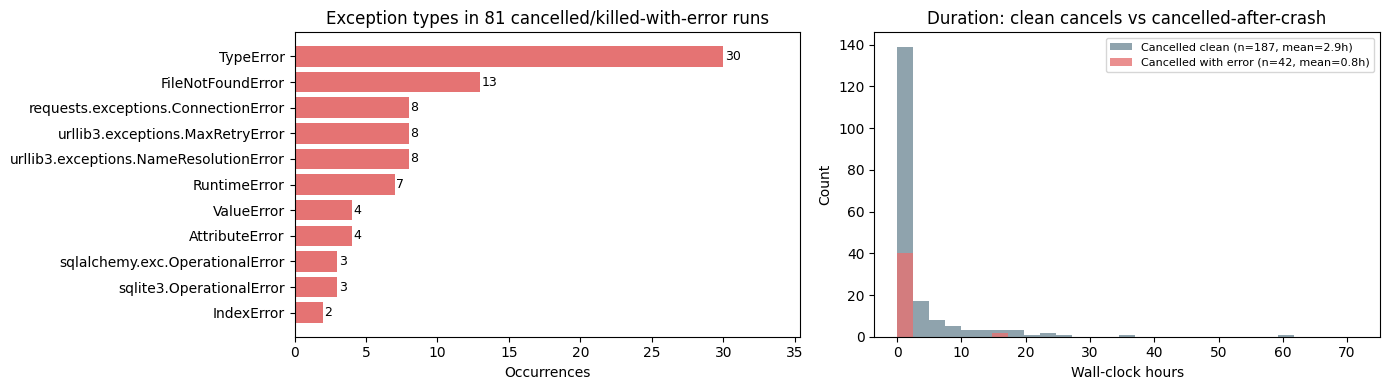


Sample log tails from cancelled-with-error runs (last 8 lines of .out):

──────────────────────────────────────────────────────────────────────
  job=10727117.0  task=11.0  exit=nan  exc=TypeError
  /home/robot/workspaces/robot_rodeo_gym_ws/logs/optuna_ftr_10727117/optuna_ftr_10727117_11/optuna_ftr_10727117_11.out
    2026-03-23 14:06:21,185 [optuna_ftr][INFO]:   gae_opts.gamma = 0.9863384390113367 (optuna_train_ftr.py:122)
    2026-03-23 14:06:21,185 [optuna_ftr][INFO]:   gae_opts.lmbda = 0.9216696255337802 (optuna_train_ftr.py:122)
    2026-03-23 14:06:21,185 [optuna_ftr][INFO]:   solver_position_iterations = 6 (optuna_train_ftr.py:122)
    2026-03-23 14:06:21,185 [optuna_ftr][INFO]:   solver_velocity_iterations = 1 (optuna_train_ftr.py:122)
    2026-03-23 14:06:21,185 [optuna_ftr][INFO]:   max_depenetration_velocity = 0.013509240735444688 (optuna_train_ftr.py:122)
    2026-03-23 14:06:21,186 [optuna_ftr][INFO]:   sim_dt = 0.003800745540439542 (optuna_train_ftr.py:122)
    2026-03-2

In [4]:
# ── Cancelled / killed runs: traceback breakdown ───────────────────────────────
# Cancelled-with-error = SLURM cancel signal present AND a Python traceback found.
# These are runs that crashed/hung and were manually cancelled before SLURM
# cleaned them up.  Killed-with-error = no cancel signal, no exit code, but
# has a traceback (e.g. OOM-killed mid-Python).

MANUAL_CANCEL_STATUSES = {"cancelled_with_error", "killed_with_error"}
err_cancel = df[df["status"].isin(MANUAL_CANCEL_STATUSES)].copy()
clean_cancel = df[df["status"] == "cancelled"].copy()

print(f"SLURM cancelled — CLEAN (no traceback) : {len(clean_cancel)}")
print(f"SLURM cancelled — WITH TRACEBACK       : {(df['status']=='cancelled_with_error').sum()}")
print(f"Killed (no exit) — WITH TRACEBACK      : {(df['status']=='killed_with_error').sum()}")
print(f"Cancelled/killed runs with tracebacks  : {len(err_cancel)}  total")
print()

if err_cancel.empty:
    print("No cancelled/killed runs with tracebacks found.")
else:
    # ── exception type frequency ──────────────────────────────────────────────
    from collections import Counter
    exc_counter: Counter = Counter()
    for exc_str in err_cancel["exception_types"].dropna():
        for exc in exc_str.split(", "):
            exc = exc.strip()
            if exc:
                exc_counter[exc] += 1

    print("Exception types in cancelled+killed-with-error runs:")
    exc_df = pd.DataFrame(exc_counter.most_common(20),
                           columns=["exception_type", "count"])
    display(exc_df)
    print()

    # ── per-job breakdown ─────────────────────────────────────────────────────
    job_breakdown = (
        df[df["status"].isin({"cancelled", "cancelled_with_error", "killed_with_error"})]
        .groupby(["job_id", "status"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    print("Per-job cancelled breakdown:")
    display(job_breakdown)
    print()

    # ── Figure: exception type bar + hours distribution ───────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    if exc_df.empty:
        ax.text(0.5, 0.5, "No exception types parsed", ha="center", va="center",
                transform=ax.transAxes)
    else:
        top = exc_df.head(12)
        bars = ax.barh(top["exception_type"][::-1], top["count"][::-1], color="#e57373")
        for bar, val in zip(bars, top["count"][::-1].values):
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                    str(val), va="center", fontsize=9)
        ax.margins(x=0.18)
        ax.set_xlabel("Occurrences")
        ax.set_title(f"Exception types in {len(err_cancel)} cancelled/killed-with-error runs")

    ax = axes[1]
    h_with = err_cancel["hours"].dropna()
    h_clean = clean_cancel["hours"].dropna()
    bins = np.linspace(0, max(df["hours"].max() or 1, 1), 30)
    if len(h_clean):
        ax.hist(h_clean, bins=bins, alpha=0.7, color="#607d8b",
                label=f"Cancelled clean (n={len(h_clean)}, mean={h_clean.mean():.1f}h)")
    if len(h_with):
        ax.hist(h_with, bins=bins, alpha=0.8, color="#e57373",
                label=f"Cancelled with error (n={len(h_with)}, mean={h_with.mean():.1f}h)")
    ax.set_xlabel("Wall-clock hours")
    ax.set_ylabel("Count")
    ax.set_title("Duration: clean cancels vs cancelled-after-crash")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # ── sample of the actual error messages ───────────────────────────────────
    print("\nSample log tails from cancelled-with-error runs (last 8 lines of .out):")
    sample = err_cancel.sample(min(5, len(err_cancel)), random_state=42)
    for _, row in sample.iterrows():
        p = Path(row["out_path"])
        tail = p.read_text(errors="replace").splitlines()[-8:]
        print(f"\n{'─'*70}")
        print(f"  job={row['job_id']}  task={row['task_id']}  "
              f"exit={row['exit_code']}  exc={row['exception_types']}")
        print(f"  {p}")
        for line in tail:
            print(f"    {line}")


/tmp/ipykernel_711058/653172440.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels[::-1], fontsize=YLABEL_FONTSIZE)


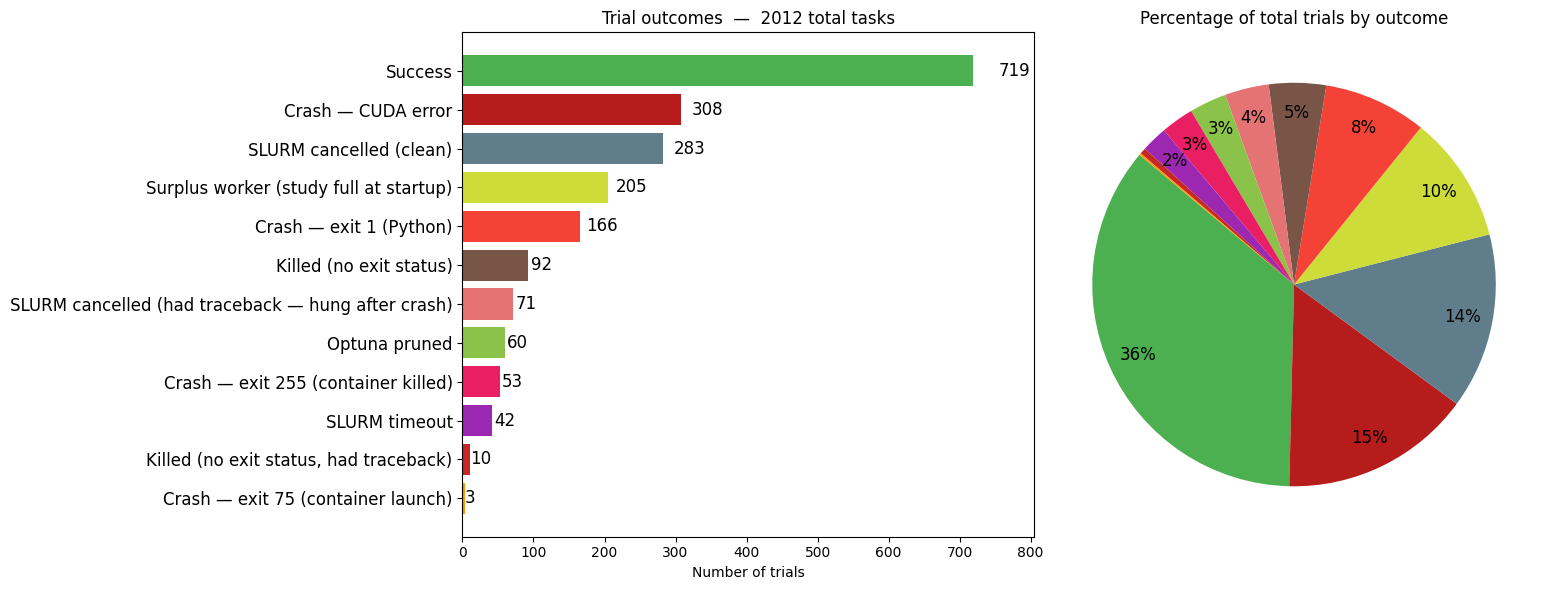

In [16]:
# ── Figure 1: outcome bar chart with pie inset ────────────────────────────────
YLABEL_FONTSIZE = 12
COLORS = {
    "success":                    "#4caf50",
    "pruned":                     "#8bc34a",
    "exit0_no_result":            "#cddc39",
    "crash_cuda":                 "#b71c1c",
    "crash_1_python":             "#f44336",
    "crash_75_container_launch":  "#ff9800",
    "crash_255_container_killed": "#e91e63",
    "timeout":                    "#9c27b0",
    "cancelled":                  "#607d8b",
    "cancelled_with_error":       "#e57373",
    "killed_no_exit":             "#795548",
    "killed_with_error":          "#c62828",
}

counts = df["status"].value_counts()
labels = [STATUS_LABELS.get(s, s) for s in counts.index]
colors = [COLORS.get(s, "#90a4ae") for s in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# — bar chart
ax = axes[0]
bars = ax.barh(labels[::-1], counts.values[::-1], color=colors[::-1])
ax.set_xlabel("Number of trials")
ax.set_yticklabels(labels[::-1], fontsize=YLABEL_FONTSIZE)
ax.set_title(f"Trial outcomes  —  {len(df)} total tasks")
for bar, val in zip(bars, counts.values[::-1]):
    ax.text(bar.get_width() + 0.05*bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f"{val}", va="center", fontsize=YLABEL_FONTSIZE)
ax.margins(x=0.12)

# Pie inset — lower-right corner in figure coordinates [left, bottom, width, height]
ax_pie = axes[1]
ax_pie.pie(
    counts.values,
    colors=colors,
    autopct=lambda p: f"{p:.0f}%" if p >= 2 else "",
    startangle=140,
    textprops={"fontsize": 12},
    pctdistance=0.85,
)
ax_pie.set_aspect("equal")
ax_pie.set_title("Percentage of total trials by outcome")

plt.tight_layout()
plt.savefig(fname="images/slurm_audit_crash_pct.svg",format="svg")
plt.show()


/tmp/ipykernel_711058/3646531279.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(crash_labels[::-1], fontsize=YLABEL_FONTSIZE)


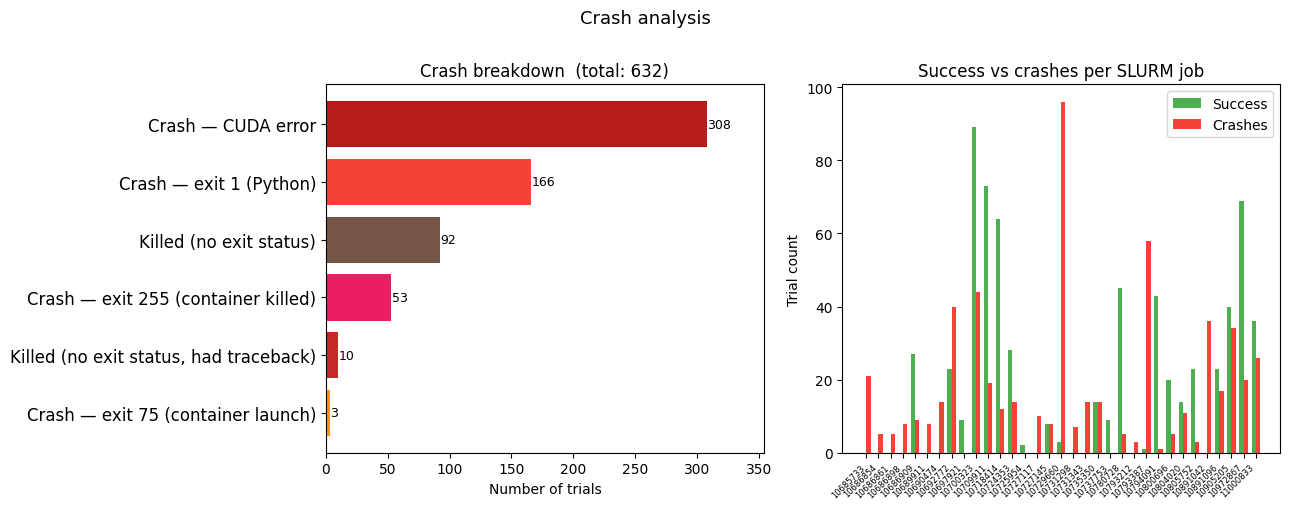


Total crashes: 632  (31.4%)
Total success: 719  (35.7%)


In [6]:
# ── Figure 2: crash breakdown + success/crash totals ─────────────────────────
crash_df     = df[df["status"].isin(CRASH_STATUSES)]
crash_counts = crash_df["status"].value_counts()
crash_labels = [STATUS_LABELS.get(s, s) for s in crash_counts.index]
crash_colors = [COLORS.get(s, "#90a4ae") for s in crash_counts.index]

total_success = (df["status"] == "success").sum()
total_crashes = crash_df.shape[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — crash breakdown
ax = axes[0]
if total_crashes:
    bars = ax.barh(crash_labels[::-1], crash_counts.values[::-1], color=crash_colors[::-1])
    for bar, val in zip(bars, crash_counts.values[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val}", va="center", fontsize=9)
    ax.margins(x=0.15)
else:
    ax.text(0.5, 0.5, "No crashes found", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
ax.set_xlabel("Number of trials")
ax.set_yticklabels(crash_labels[::-1], fontsize=YLABEL_FONTSIZE)
ax.set_title(f"Crash breakdown  (total: {total_crashes})")

# — success vs crash stacked comparison per job
ax = axes[1]
grp = df.groupby(["job_id", "status"]).size().unstack(fill_value=0)
success_per_job = grp.get("success", pd.Series(0, index=grp.index))
crash_per_job   = sum(
    grp.get(s, pd.Series(0, index=grp.index)) for s in CRASH_STATUSES
)
job_df = pd.DataFrame({"success": success_per_job, "crash": crash_per_job})
job_df = job_df[job_df.sum(axis=1) > 0].sort_index()

x = np.arange(len(job_df))
w = 0.35
ax.bar(x - w/2, job_df["success"], w, label="Success", color="#4caf50")
ax.bar(x + w/2, job_df["crash"],   w, label="Crashes", color="#f44336")
ax.set_xticks(x)
ax.set_xticklabels([str(int(j)) for j in job_df.index], rotation=45, ha="right", fontsize=6)
ax.set_ylabel("Trial count")
ax.set_title("Success vs crashes per SLURM job")
ax.legend()

plt.suptitle("Crash analysis", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nTotal crashes: {total_crashes}  ({100*total_crashes/len(df):.1f}%)")
print(f"Total success: {total_success}  ({100*total_success/len(df):.1f}%)")


/tmp/ipykernel_711058/3557901653.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(h_labels[::-1], fontsize=YLABEL_FONTSIZE)
/tmp/ipykernel_711058/3557901653.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(h_labels[::-1], fontsize=YLABEL_FONTSIZE)


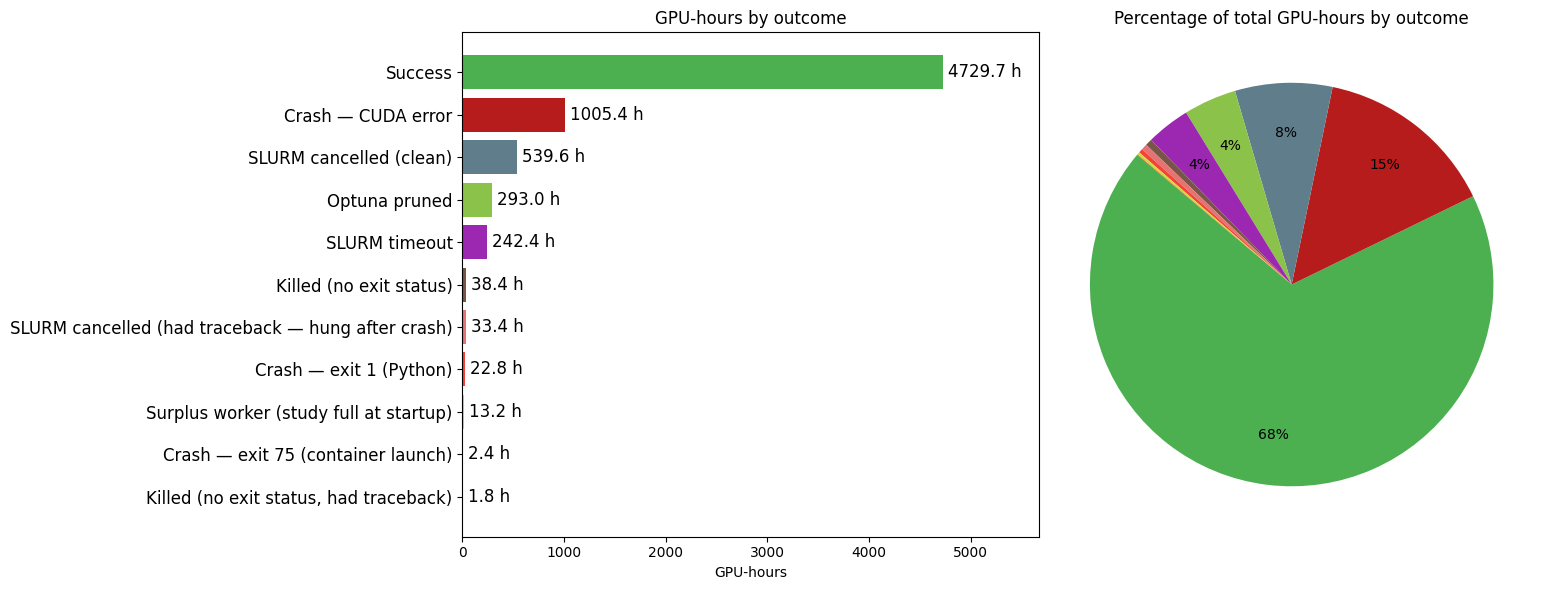

GPU-hours measured (trials with timing): 6922.2 h  (1655 of 2012 trials)
  Successful trials : 4729.7 h  (68.3%)
  Crashed trials    : 1070.8 h  (15.5%)
  Timeout/cancelled : 782.0 h  (11.3%)
  Pruned            : 293.0 h  (4.2%)


In [19]:
# ── Figure 3a: GPU-hours by outcome ───────────────────────────────────────────
has_hours = df[df["hours"].notna()].copy()

if has_hours.empty:
    print("WARNING: no timing data found — check that _parse_header_dt and "
          "_parse_max_tqdm_elapsed are matching log content.")
else:
    hour_by_status = has_hours.groupby("status")["hours"].sum().sort_values(ascending=False)
    h_labels = [STATUS_LABELS.get(s, s) for s in hour_by_status.index]
    h_colors = [COLORS.get(s, "#90a4ae")  for s in hour_by_status.index]

    success_hours  = has_hours.loc[has_hours["status"] == "success", "hours"].sum()
    crashed_hours  = has_hours.loc[has_hours["status"].isin(CRASH_STATUSES), "hours"].sum()
    timeout_hours  = has_hours.loc[has_hours["status"].isin({"timeout", "cancelled"}), "hours"].sum()
    pruned_hours   = has_hours.loc[has_hours["status"] == "pruned", "hours"].sum()
    total_measured = has_hours["hours"].sum()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax = axes[0]
    ax.grid(False)
    bars = ax.barh(h_labels[::-1], hour_by_status.values[::-1], color=h_colors[::-1])
    ax.set_yticklabels(h_labels[::-1], fontsize=YLABEL_FONTSIZE)
    for bar, val in zip(bars, hour_by_status.values[::-1]):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f} h", va="center", fontsize=YLABEL_FONTSIZE)
    ax.margins(x=0.2)
    ax.set_xlabel("GPU-hours")
    ax.set_yticklabels(h_labels[::-1], fontsize=YLABEL_FONTSIZE)
    ax.set_title("GPU-hours by outcome")

    ax_pie = axes[1]
    wedges, _,_ = ax_pie.pie(
        hour_by_status.values,
        colors=h_colors,          # h_colors matches hour_by_status ordering
        autopct=lambda p: f"{p:.0f}%" if p >= 2 else "",
        startangle=140,
        textprops={"fontsize": 10},
        pctdistance=0.75,
    )
    ax_pie.set_aspect("equal")
    ax_pie.set_title("Percentage of total GPU-hours by outcome")
    #ax_pie.legend(wedges, h_labels, loc="lower right", fontsize=8, ncol=2)

    plt.tight_layout()
    plt.savefig(fname="images/slurm_audit_crash_hours.svg",format="svg")
    plt.show()

    def pct(x): return f"{100*x/total_measured:.1f}%" if total_measured else "N/A"
    print(f"GPU-hours measured (trials with timing): {total_measured:.1f} h  "
          f"({has_hours.shape[0]} of {len(df)} trials)")
    print(f"  Successful trials : {success_hours:.1f} h  ({pct(success_hours)})")
    print(f"  Crashed trials    : {crashed_hours:.1f} h  ({pct(crashed_hours)})")
    print(f"  Timeout/cancelled : {timeout_hours:.1f} h  ({pct(timeout_hours)})")
    print(f"  Pruned            : {pruned_hours:.1f} h  ({pct(pruned_hours)})")


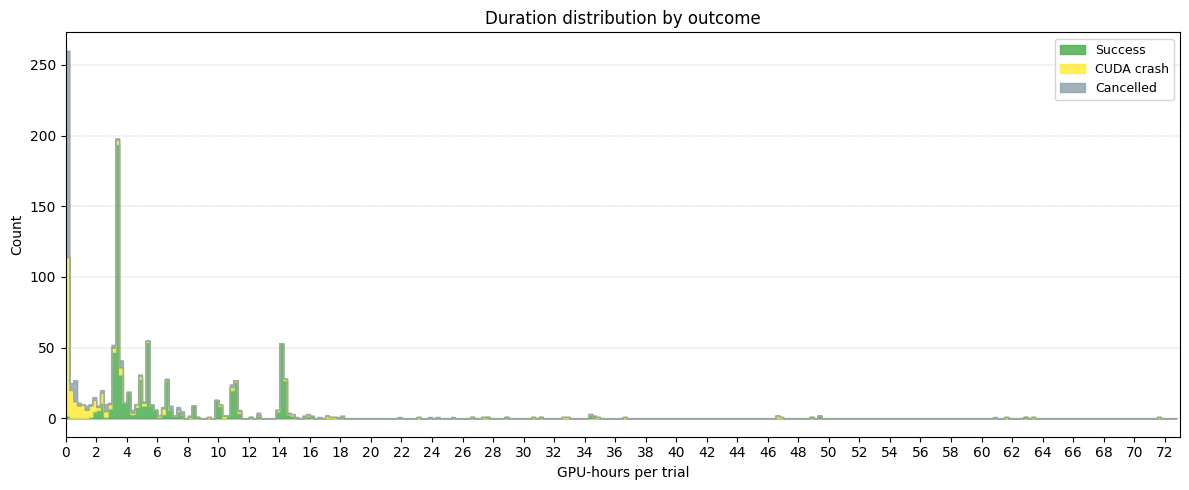

In [8]:
# ── Figure 3b: duration distribution — stacked steps by outcome ───────────────
_GROUPS = [
    ("success",       "Success",        "#4caf50"),
    ("crash_cuda",    "CUDA crash",     "#ffeb3b"),
    #("crash_other",   "Other crashes",  "#f44336"),
    #("timeout",       "Timeout",        "#9c27b0"),
    ("cancelled",     "Cancelled",      "#90a4ae"),
]

def _to_group(s):
    if s == "success":                             return "success"
    if s == "crash_cuda":                          return "crash_cuda"
    #if s in CRASH_STATUSES:                        return "crash_other"
    #if s == "timeout":                             return "timeout"
    if s in {"cancelled", "cancelled_with_error"}: return "cancelled"
    return None

_hdf = has_hours.copy()
_hdf["group"] = _hdf["status"].map(_to_group)
_hdf = _hdf[_hdf["group"].notna() & _hdf["hours"].notna()]

_max_h = int(_hdf["hours"].max()) + 2
bins_s = np.arange(0, _max_h + 0.25, 0.25)

_counts = {}
for key, *_ in _GROUPS:
    h = _hdf.loc[_hdf["group"] == key, "hours"]
    _counts[key], _ = np.histogram(h, bins=bins_s)

fig, ax = plt.subplots(figsize=(12, 5))
cumsum = np.zeros(len(bins_s) - 1)
for key, label, color in _GROUPS:
    prev = cumsum.copy()
    cumsum += _counts[key]
    ax.fill_between(bins_s[:-1], prev, cumsum, step="post", alpha=0.85,
                    color=color, label=label)

ax.set_xlabel("GPU-hours per trial")
ax.set_ylabel("Count")
ax.set_title("Duration distribution by outcome")
ax.set_xticks(range(0, _max_h, 2))
ax.grid(True, "major", "y", color="gray", linestyle="--", linewidth=0.2)
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, _max_h)
plt.tight_layout()
plt.show()


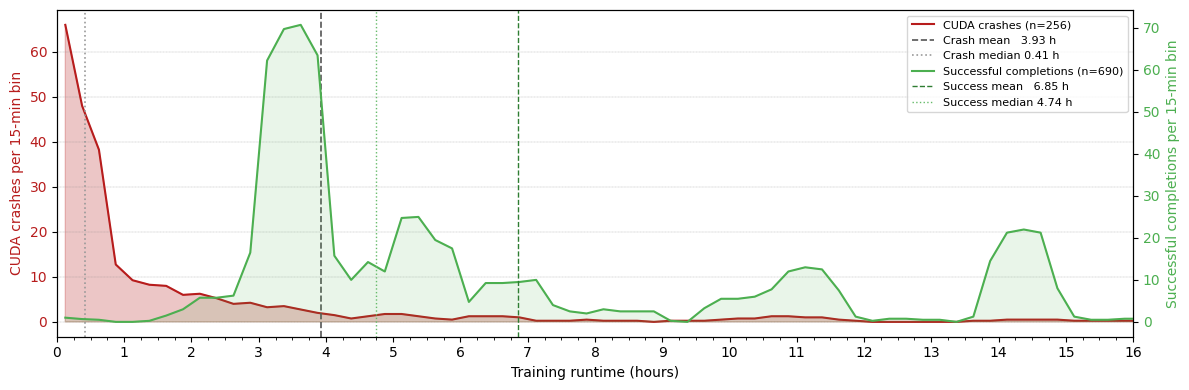

Crashes in first 30 min : 132  (52%)
Crashes in first 2 h    : 185  (72%)
Crashes after 16 h      : 17  (8%)
Success mean finish     : 6.85 h  median 4.74 h


In [18]:
# ── Figure: when during training do CUDA crashes occur? ───────────────────────
_cuda    = df[(df["status"] == "crash_cuda") & df["hours"].notna()].copy()
_success = df[(df["status"] == "success")    & df["hours"].notna()].copy()

_max_h = int(max(_cuda["hours"].max(), _success["hours"].max())) + 1
bins   = np.arange(0, _max_h + 0.25, 0.25)   # 15-min buckets
centers = (bins[:-1] + bins[1:]) / 2

crash_counts,   _ = np.histogram(_cuda["hours"],    bins=bins)
success_counts, _ = np.histogram(_success["hours"], bins=bins)

_smooth_crash   = pd.Series(crash_counts).rolling(window=4, center=True, min_periods=1).mean()
_smooth_success = pd.Series(success_counts).rolling(window=4, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 4))

# ── CUDA crash density (left axis) ───────────────────────────────────────────
ax.fill_between(centers, _smooth_crash, alpha=0.25, color="#b71c1c")
ax.plot(centers, _smooth_crash, color="#b71c1c", linewidth=1.5,
        label=f"CUDA crashes (n={len(_cuda)})")
ax.axvline(_cuda["hours"].mean(),   color="#555", linewidth=1.2,
           linestyle="--", label=f"Crash mean   {_cuda['hours'].mean():.2f} h")
ax.axvline(_cuda["hours"].median(), color="#999", linewidth=1.2,
           linestyle=":" , label=f"Crash median {_cuda['hours'].median():.2f} h")
ax.set_xlabel("Training runtime (hours)")
ax.set_ylabel("CUDA crashes per 15-min bin", color="#b71c1c")
ax.tick_params(axis="y", labelcolor="#b71c1c")

# ── Success finish distribution (right axis) ──────────────────────────────────
ax2 = ax.twinx()
ax2.fill_between(centers, _smooth_success, alpha=0.12, color="#4caf50")
ax2.plot(centers, _smooth_success, color="#4caf50", linewidth=1.5, linestyle="-",
         label=f"Successful completions (n={len(_success)})")
ax2.axvline(_success["hours"].mean(),   color="#2e7d32", linewidth=1.0,
            linestyle="--", label=f"Success mean   {_success['hours'].mean():.2f} h")
ax2.axvline(_success["hours"].median(), color="#66bb6a", linewidth=1.0,
            linestyle=":" , label=f"Success median {_success['hours'].median():.2f} h")
ax2.set_ylabel("Successful completions per 15-min bin", color="#4caf50")
ax2.tick_params(axis="y", labelcolor="#4caf50")

# ── Shared formatting ─────────────────────────────────────────────────────────
ax.set_xticks(range(0, _max_h + 1, 1))
ax.set_xticks(np.arange(0, _max_h + 1, 0.25), minor=True)
ax.grid(True, "major", "y", color="gray", linestyle="--", linewidth=0.2)
ax.set_xlim(0, 16)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(fname="images/slurm_audit_crash_dist.svg",format="svg")
plt.show()

print(f"Crashes in first 30 min : {(_cuda['hours'] < 0.5).sum()}  "
      f"({100*(_cuda['hours'] < 0.5).mean():.0f}%)")
print(f"Crashes in first 2 h    : {(_cuda['hours'] < 2.0).sum()}  "
      f"({100*(_cuda['hours'] < 2.0).mean():.0f}%)")
print(f"Crashes after 16 h      : {(_cuda['hours'] > 16.0).sum()}  "
      f"({100*(_cuda['hours'] > 12.0).mean():.0f}%)")
print(f"Success mean finish     : {_success['hours'].mean():.2f} h  "
      f"median {_success['hours'].median():.2f} h")


Reading log headers for calendar timestamps …
  1874 trials with calendar timestamps


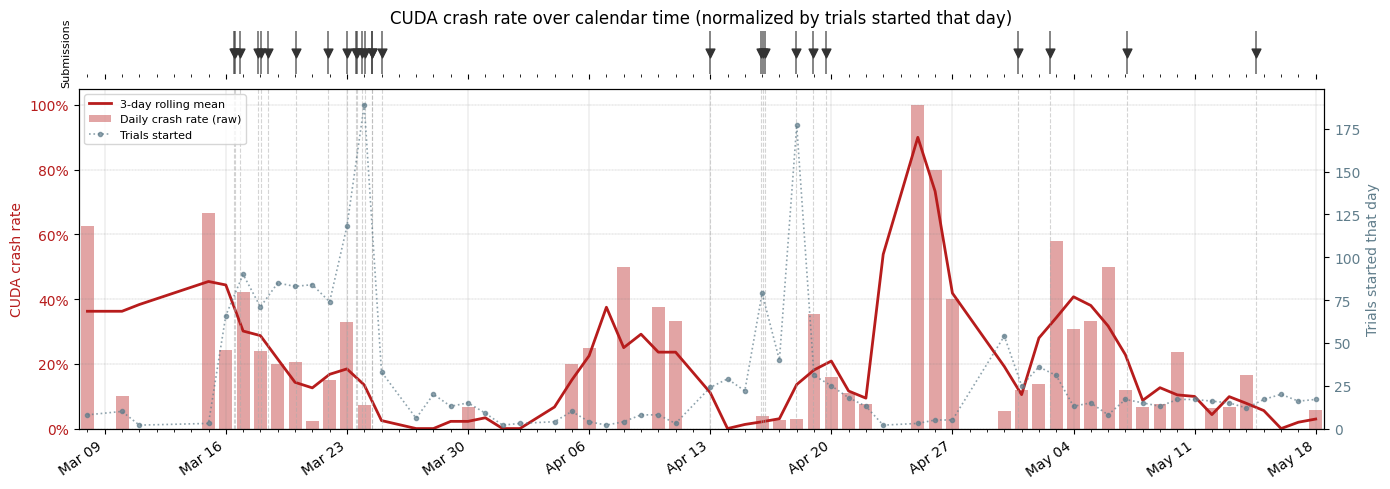

      date  total  cuda_crashes rate
2026-03-08      8             5  62%
2026-03-10     10             1  10%
2026-03-15      3             2  67%
2026-03-16     66            16  24%
2026-03-17     90            38  42%
2026-03-18     71            17  24%
2026-03-19     85            17  20%
2026-03-20     83            17  20%
2026-03-21     84             2   2%
2026-03-22     74            11  15%
2026-03-23    118            39  33%
2026-03-24    189            14   7%
2026-03-25     33             0   0%
2026-03-27      6             0   0%
2026-03-28     20             0   0%
2026-03-29     13             0   0%
2026-03-30     15             1   7%
2026-03-31      9             0   0%
2026-04-02      3             0   0%
2026-04-04      4             0   0%
2026-04-05     10             2  20%
2026-04-06      4             1  25%
2026-04-08      4             2  50%
2026-04-09      8             0   0%
2026-04-10      8             3  38%
2026-04-11      3             1  33%
2

In [10]:
# ── Figure: CUDA crash rate over calendar time (normalized) ─────────────────
import matplotlib.dates as mdates
from datetime import timedelta
from matplotlib.transforms import blended_transform_factory

# Fast header-only datetime extraction (first 20 lines of each .out file)
def _read_start_dt(out_path):
    try:
        with open(out_path, errors="replace") as fh:
            head = "".join(fh.readline() for _ in range(20))
        return _parse_header_dt(head)
    except OSError:
        return None

print("Reading log headers for calendar timestamps …")
_cal = df[df["out_path"].notna()].copy()
_cal["start_dt"] = pd.to_datetime([_read_start_dt(p) for p in _cal["out_path"]])
_cal = _cal[_cal["start_dt"].notna()].copy()
_cal["date"]     = _cal["start_dt"].dt.normalize()
print(f"  {len(_cal)} trials with calendar timestamps")

# ── Per-day stats ─────────────────────────────────────────────────────────────
_daily = (
    _cal.groupby("date")
        .agg(total=("status", "count"),
             cuda_crashes=("status", lambda s: (s == "crash_cuda").sum()))
        .reset_index()
)
_daily["rate"] = _daily["cuda_crashes"] / _daily["total"].clip(lower=1)
# Suppress days with fewer than 3 trials (too noisy to normalise meaningfully)
_daily.loc[_daily["total"] < 3, "rate"] = float("nan")
_smooth_rate = _daily["rate"].rolling(3, center=True, min_periods=1).mean()

# ── Job-array submission times (one mark per unique job_id) ───────────────────
_job_starts = (
    _cal[_cal["job_id"].notna()]
    .groupby("job_id")["start_dt"]
    .min()
    .sort_values()
)
# Merge submissions within 30 min of each other into one mark to reduce clutter
_merged_marks = []
_prev = None
for t in _job_starts:
    if _prev is None or (t - _prev).total_seconds() > 1800:
        _merged_marks.append(t)
        _prev = t
_mark_times = pd.DatetimeIndex(_merged_marks)

# ── Layout: thin rug strip on top, main chart below ──────────────────────────
fig, (ax_rug, ax) = plt.subplots(
    2, 1, figsize=(14, 5),
    gridspec_kw={"height_ratios": [1, 8]},
    sharex=True,
)
fig.subplots_adjust(hspace=0.04)

# ── Rug strip ─────────────────────────────────────────────────────────────────
ax_rug.set_xlim(_daily["date"].min() - timedelta(days=0.5),
                _daily["date"].max() + timedelta(days=0.5))
ax_rug.set_ylim(0, 1)
for t in _mark_times:
    ax_rug.axvline(t, color="#333", linewidth=1.2, alpha=0.7)
ax_rug.scatter(_mark_times, [0.5] * len(_mark_times),
               marker="v", s=40, color="#333", zorder=5)
ax_rug.set_yticks([])
ax_rug.set_ylabel("Submissions", fontsize=8, labelpad=2)
for spine in ["top", "left", "right", "bottom"]:
    ax_rug.spines[spine].set_visible(False)
ax_rug.set_title("CUDA crash rate over calendar time (normalized by trials started that day)")

# ── Main chart ────────────────────────────────────────────────────────────────
_bar_w = timedelta(hours=18)
ax.bar(_daily["date"], _daily["rate"], width=_bar_w, color="#b71c1c", alpha=0.4,
       align="center", label="Daily crash rate (raw)")
ax.plot(_daily["date"], _smooth_rate, color="#b71c1c", linewidth=2,
        label="3-day rolling mean")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("CUDA crash rate", color="#b71c1c")
ax.tick_params(axis="y", labelcolor="#b71c1c")
ax.set_ylim(0)

# Job markers on main chart too (thin lines for reference)
for t in _mark_times:
    ax.axvline(t, color="#aaa", linewidth=0.8, linestyle="--", alpha=0.5)

# ── Secondary axis: raw trial count ───────────────────────────────────────────
ax2 = ax.twinx()
ax2.plot(_daily["date"], _daily["total"], color="#607d8b", linewidth=1.2,
         linestyle=":", marker="o", markersize=3, alpha=0.7, label="Trials started")
ax2.set_ylabel("Trials started that day", color="#607d8b")
ax2.tick_params(axis="y", labelcolor="#607d8b")
ax2.set_ylim(0)

# ── X-axis formatting ─────────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_minor_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate(rotation=35, ha="right")
ax.grid(True, "major", "x", color="gray", linestyle="-",  linewidth=0.15)
ax.grid(True, "major", "y", color="gray", linestyle="--", linewidth=0.2)

# ── Combined legend ───────────────────────────────────────────────────────────
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(_daily[["date", "total", "cuda_crashes", "rate"]]
      .dropna(subset=["rate"])
      .assign(rate=lambda d: d["rate"].map("{:.0%}".format))
      .to_string(index=False))


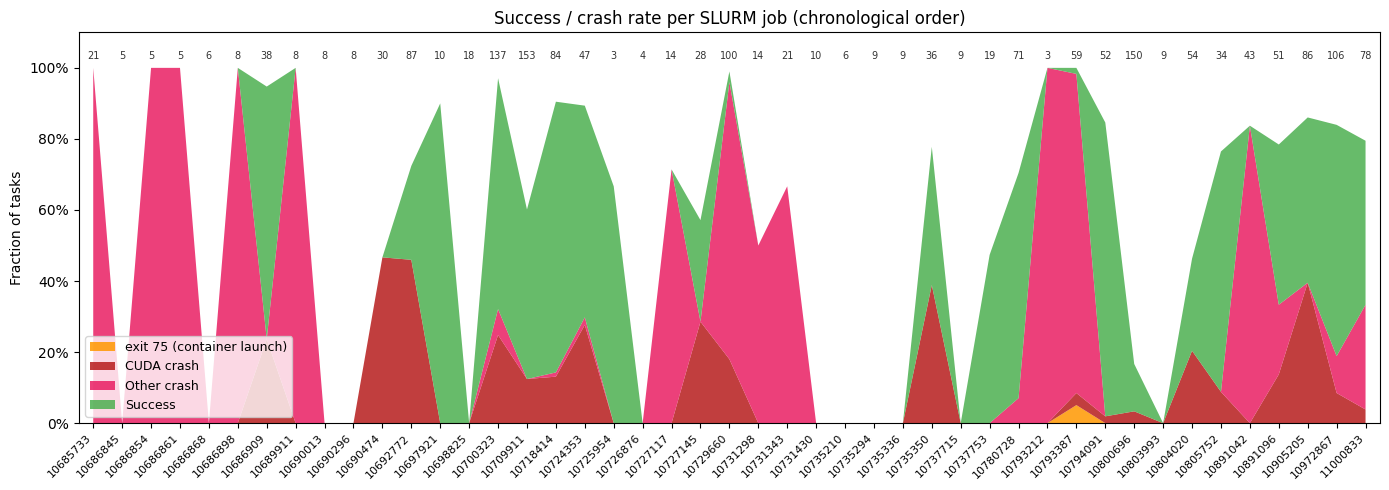

In [11]:
# ── Figure 4: crash rate over time (by SLURM job submission order) ────────────
job_order = sorted(df["job_id"].dropna().unique())

rows = []
for jid in job_order:
    sub = df[df["job_id"] == jid]
    n = len(sub)
    n_success = (sub["status"] == "success").sum()
    n_crash   = sub["status"].isin(CRASH_STATUSES).sum()
    n_cuda    = (sub["status"] == "crash_cuda").sum()
    n_launch  = (sub["status"] == "crash_75_container_launch").sum()
    n_other   = n_crash - n_cuda - n_launch
    rows.append({
        "job_id": jid, "n": n,
        "success_rate":       n_success / n,
        "cuda_crash_rate":    n_cuda / n,
        "launch_crash_rate":  n_launch / n,
        "other_crash_rate":   n_other / n,
    })

jdf = pd.DataFrame(rows)
x   = np.arange(len(jdf))
xl  = [str(int(j)) for j in jdf["job_id"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    x,
    jdf["launch_crash_rate"],
    jdf["cuda_crash_rate"],
    jdf["other_crash_rate"],
    jdf["success_rate"],
    labels=["exit 75 (container launch)", "CUDA crash",
            "Other crash", "Success"],
    colors=["#ff9800", "#b71c1c", "#e91e63", "#4caf50"],
    alpha=0.85,
)
ax.set_xticks(x)
ax.set_xticklabels(xl, rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Fraction of tasks")
ax.set_title("Success / crash rate per SLURM job (chronological order)")
ax.legend(loc="lower left", fontsize=9)

# Annotate total tasks per job
for xi, row in zip(x, jdf.itertuples()):
    ax.text(xi, 1.02, str(row.n), ha="center", va="bottom", fontsize=7, color="#333")

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()
